In [1]:
# ==== Setup ====
from pathlib import Path
import numpy as np, nibabel as nib, pandas as pd
from numpy.fft import fftn, fftshift
from scipy.ndimage import laplace
from scipy import stats
import matplotlib.pyplot as plt
import json, textwrap, datetime as dt

# Where to write combined outputs for this run
RUN_TAG = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_ROOT = Path(f"./_image_quality_eval_{RUN_TAG}")
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# ==== Dataset registry (edit if paths change) ====
BASE = Path("/home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_splits_70_30_global")
DATASETS = {
    # Baselines
    "High-Res (test_hires)" : BASE / "test_hires",
    "Low-Res (test_lores)"  : BASE / "test_lores",

    # Downsampled variants (all mapped to friendly labels)
    "Crude 2×2×5× (backTo1mm)"       : BASE / "test_hires_crude_2x2x5x_backTo1mm",
    "In-Plane 2×2×1mm (backTo1mm)"   : BASE / "test_hires_inplane_2x2x1mm_backTo1mm",
    "Motion (slice jitter)"          : BASE / "test_hires_motion_slicejitter",
    "Reduced SNR (k-space v1)"       : BASE / "test_hires_snr_kspace_v1",
    "Thick slice 1×1×5mm (backTo1mm)": BASE / "test_hires_thickslice_1x1x5mm_backTo1mm",
}

for name, p in DATASETS.items():
    assert p.exists(), f"Missing: {name} -> {p}"

print("Output dir:", OUT_ROOT)
print("Datasets:")
for k,v in DATASETS.items():
    print(" -", k, "->", v)


Output dir: _image_quality_eval_20251112_120355
Datasets:
 - High-Res (test_hires) -> /home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_splits_70_30_global/test_hires
 - Low-Res (test_lores) -> /home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_splits_70_30_global/test_lores
 - Crude 2×2×5× (backTo1mm) -> /home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_splits_70_30_global/test_hires_crude_2x2x5x_backTo1mm
 - In-Plane 2×2×1mm (backTo1mm) -> /home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_splits_70_30_global/test_hires_inplane_2x2x1mm_backTo1mm
 - Motion (slice jitter) -> /home/rbielski/ARC/ds004884/derivatives/aggregates/t

In [6]:
def zscore_in_brain(vol: np.ndarray):
    """Z-score only within nonzero voxels; return z-img and boolean mask."""
    m = vol != 0
    out = np.zeros_like(vol, dtype=np.float32)
    if m.any():
        v = vol[m].astype(np.float32)
        mu, sd = v.mean(), v.std() if v.std() > 0 else 1.0
        out[m] = (vol[m] - mu) / sd
    return out, m

# ---- Robust guards for metrics ----
import numpy as np

def estimate_fwhm_gaussian_acf(img: np.ndarray, mask: np.ndarray, shifts=(1,2,3),
                               max_fwhm_mm=50.0, min_pairs=1000) -> float:
    """Return NaN if the Gaussian fit is ill-posed or unphysical."""
    cors = []
    for s in shifts:
        for axis in (0,1,2):
            slicer_f = [slice(None)]*3
            slicer_g = [slice(None)]*3
            slicer_f[axis] = slice(0, -s)
            slicer_g[axis] = slice(s, None)
            f = img[tuple(slicer_f)]; g = img[tuple(slicer_g)]
            m = mask[tuple(slicer_f)] & mask[tuple(slicer_g)]
            if m.sum() < min_pairs:
                continue
            fv = f[m] - f[m].mean(); gv = g[m] - g[m].mean()
            sd = (fv.std() * gv.std())
            if sd <= 1e-8: 
                continue
            r = float((fv*gv).mean() / sd)
            # clamp R into (0,1) where log is meaningful and avoid negative/zero
            r = max(min(r, 0.999), 1e-6)
            cors.append((s, r))
    if not cors:
        return float("nan")

    # average by shift
    bys = {}
    for s, r in cors: bys.setdefault(s, []).append(r)
    s2 = np.array(sorted(bys), dtype=float)**2
    R  = np.array([np.mean(bys[s]) for s in sorted(bys)], dtype=float)

    lnR = np.log(R)
    if not np.all(np.isfinite(lnR)): 
        return float("nan")

    A = np.vstack([np.ones_like(s2), s2]).T
    a, b = np.linalg.lstsq(A, lnR, rcond=None)[0]
    # b should be negative; if slope ~0 or positive, bail
    if not np.isfinite(b) or b >= -1e-6:
        return float("nan")

    sigma = np.sqrt(-1.0/(2.0*b))
    fwhm = 2.355 * sigma

    # reject unphysical outliers (e.g., > 50 mm in 1 mm voxels)
    if not np.isfinite(fwhm) or fwhm <= 0 or fwhm > max_fwhm_mm:
        return float("nan")
    return float(fwhm)

def high_freq_energy_ratio(img: np.ndarray, mask: np.ndarray, cutoff=0.25) -> float:
    """Return NaN if total spectral power is ~0; otherwise regular HFE."""
    from numpy.fft import fftn, fftshift
    vol = np.zeros_like(img, dtype=np.float32)
    vol[mask] = img[mask]
    F = fftshift(fftn(vol))
    P = (np.abs(F)**2).astype(np.float64)
    tot = P.sum()
    if not np.isfinite(tot) or tot <= 1e-12:
        return float("nan")

    nx, ny, nz = img.shape
    cx, cy, cz = (np.array(img.shape)-1)/2.0
    x = np.arange(nx) - cx
    y = np.arange(ny) - cy
    z = np.arange(nz) - cz
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
    rx = np.abs(X) / (nx/2.0); ry = np.abs(Y) / (ny/2.0); rz = np.abs(Z) / (nz/2.0)
    r = np.sqrt((rx**2 + ry**2 + rz**2)/3.0)

    hf = P[r >= cutoff].sum()
    return float(hf / (tot + 1e-12))

def laplacian_variance(img: np.ndarray, mask: np.ndarray) -> float:
    """Variance of Laplacian on the z-scored image; larger ⇒ sharper."""
    L = laplace(img)
    return float(L[mask].var())


In [7]:
def scan_dir(dir_path: Path, dataset_name: str):
    out = []
    files = sorted([*dir_path.glob("*.nii"), *dir_path.glob("*.nii.gz")])
    for p in files:
        try:
            img = nib.load(str(p)).get_fdata().astype(np.float32)
            zimg, m = zscore_in_brain(img)
            if m.sum() < 5000:
                continue
            fwhm = estimate_fwhm_gaussian_acf(zimg, m)
            hfe  = high_freq_energy_ratio(zimg, m, cutoff=0.25)
            lvar = laplacian_variance(zimg, m)
            out.append(dict(dataset=dataset_name, path=str(p), fwhm_mm=fwhm,
                            hi_freq_energy=hfe, lap_var=lvar))
        except Exception as e:
            out.append(dict(dataset=dataset_name, path=str(p),
                            fwhm_mm=np.nan, hi_freq_energy=np.nan, lap_var=np.nan))
    return out

# Run across all datasets
all_rows = []
for name, path in DATASETS.items():
    rows = scan_dir(path, name)
    print(f"{name}: {len(rows)} files")
    all_rows.extend(rows)

df = pd.DataFrame(all_rows)
CSV_PATH = OUT_ROOT / "effective_resolution_metrics_ALL.csv"
df.to_csv(CSV_PATH, index=False)
print("Wrote:", CSV_PATH)

# quick peek
df.head()


High-Res (test_hires): 236 files
Low-Res (test_lores): 335 files
Crude 2×2×5× (backTo1mm): 236 files
In-Plane 2×2×1mm (backTo1mm): 236 files
Motion (slice jitter): 236 files
Reduced SNR (k-space v1): 236 files
Thick slice 1×1×5mm (backTo1mm): 236 files
Wrote: _image_quality_eval_20251112_120355/effective_resolution_metrics_ALL.csv


,dataset,path,fwhm_mm,hi_freq_energy,lap_var
0,High-Res (test_hires),/home/rbielski/ARC/ds004884/derivatives/aggreg...,9.377495,0.131998,2.646504
1,High-Res (test_hires),/home/rbielski/ARC/ds004884/derivatives/aggreg...,NaN,NaN,0.000000
2,High-Res (test_hires),/home/rbielski/ARC/ds004884/derivatives/aggreg...,8.876189,0.117649,2.148141
3,High-Res (test_hires),/home/rbielski/ARC/ds004884/derivatives/aggreg...,NaN,NaN,0.000000
4,High-Res (test_hires),/home/rbielski/ARC/ds004884/derivatives/aggreg...,9.783152,0.125409,2.399140


In [8]:
def summarize_df(df: pd.DataFrame, by="dataset"):
    lines = []
    for dname in sorted(df[by].unique()):
        d = df[df[by]==dname]
        lines.append(f"\n=== {dname} — N={len(d)} ===")
        for col, desc in [
            ("fwhm_mm", "FWHM blur (mm, smaller=sharper)"),
            ("hi_freq_energy", "High-freq energy fraction (larger=sharper)"),
            ("lap_var", "Variance of Laplacian (larger=sharper)")
        ]:
            v = d[col].dropna().to_numpy()
            if v.size == 0:
                lines.append(f"  {desc}: (no data)")
                continue
            p10, p50, p90 = np.percentile(v, [10,50,90])
            lines.append(f"  {desc}: p10/50/90 = {p10:.3f} / {p50:.3f} / {p90:.3f} | mean±sd = {v.mean():.3f}±{v.std():.3f}")
    return "\n".join(lines)

summary_text = summarize_df(df)
print(summary_text)

(OUT_ROOT / "summary_percentiles.txt").write_text(summary_text)



=== Crude 2×2×5× (backTo1mm) — N=236 ===
  FWHM blur (mm, smaller=sharper): p10/50/90 = 7.661 / 8.640 / 9.751 | mean±sd = 8.641±0.798
  High-freq energy fraction (larger=sharper): p10/50/90 = 0.133 / 0.160 / 0.187 | mean±sd = 0.160±0.023
  Variance of Laplacian (larger=sharper): p10/50/90 = 0.000 / 1.841 / 2.446 | mean±sd = 1.269±1.097

=== High-Res (test_hires) — N=236 ===
  FWHM blur (mm, smaller=sharper): p10/50/90 = 6.763 / 7.834 / 8.894 | mean±sd = 7.790±0.822
  High-freq energy fraction (larger=sharper): p10/50/90 = 0.080 / 0.123 / 0.160 | mean±sd = 0.122±0.028
  Variance of Laplacian (larger=sharper): p10/50/90 = 0.000 / 1.416 / 2.563 | mean±sd = 1.181±1.080

=== In-Plane 2×2×1mm (backTo1mm) — N=236 ===
  FWHM blur (mm, smaller=sharper): p10/50/90 = 9.846 / 10.827 / 12.764 | mean±sd = 11.131±1.160
  High-freq energy fraction (larger=sharper): p10/50/90 = 0.056 / 0.063 / 0.073 | mean±sd = 0.064±0.007
  Variance of Laplacian (larger=sharper): p10/50/90 = 0.000 / 0.736 / 0.916 | m

2385

In [9]:
BASE_HI = "High-Res (test_hires)"
BASE_LO = "Low-Res (test_lores)"

from scipy import stats

def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    x = x[np.isfinite(x)]; y = y[np.isfinite(y)]
    if x.size==0 or y.size==0: return np.nan
    xy = np.concatenate([x,y])
    ranks = stats.rankdata(xy)
    rx = ranks[:len(x)]
    U = np.sum(rx) - len(x)*(len(x)+1)/2
    delta = (2*U)/(len(x)*len(y)) - 1
    return float(delta)

def bootstrap_ci(a, stat=np.mean, nboot=2000, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    a = np.asarray(a); a = a[np.isfinite(a)]
    if a.size==0: return np.nan, (np.nan, np.nan)
    boots = [stat(rng.choice(a, size=a.size, replace=True)) for _ in range(nboot)]
    lo, hi = np.percentile(boots, [100*alpha/2, 100*(1-alpha/2)])
    return float(stat(a)), (float(lo), float(hi))

def hodges_lehmann_shift(x, y):
    """Robust median difference estimator (HL)."""
    x = np.asarray(x); y = np.asarray(y)
    x = x[np.isfinite(x)]; y = y[np.isfinite(y)]
    if x.size==0 or y.size==0: return np.nan
    diffs = (y.reshape(-1,1) - x.reshape(1,-1)).ravel()
    return float(np.median(diffs))

def compare_against(df, base_name, metrics=("fwhm_mm","hi_freq_energy","lap_var")):
    rows = []
    base = df[df["dataset"]==base_name]
    for dname in df["dataset"].unique():
        if dname == base_name: 
            continue
        cur = df[df["dataset"]==dname]
        for col in metrics:
            x = base[col].to_numpy()
            y = cur[col].to_numpy()
            x_clean = x[np.isfinite(x)]
            y_clean = y[np.isfinite(y)]

            if x_clean.size<3 or y_clean.size<3:
                U = p = np.nan
            else:
                U, p = stats.mannwhitneyu(x_clean, y_clean, alternative="two-sided")

            delta = cliffs_delta(y_clean, x_clean)  # positive => group > base
            mu_base, ci_base = bootstrap_ci(x_clean, stat=np.mean)
            mu_group, ci_group = bootstrap_ci(y_clean, stat=np.mean)
            pct = 100.0 * (mu_group - mu_base) / abs(mu_base) if np.isfinite(mu_base) and mu_base!=0 else np.nan
            # also report robust median and HL shift
            med_base, _ = bootstrap_ci(x_clean, stat=np.median)
            med_group, _ = bootstrap_ci(y_clean, stat=np.median)
            hl = hodges_lehmann_shift(x_clean, y_clean)

            rows.append(dict(
                compare_to=base_name,
                dataset=dname,
                metric=col,
                U=U, p=p,
                cliffs_delta=delta,
                mean_base=mu_base, mean_group=mu_group,
                ci_lo=ci_group[0], ci_hi=ci_group[1],
                pct_vs_base=pct,
                median_base=med_base, median_group=med_group,
                HL_shift=hl,
                n_base=int(x_clean.size), n_group=int(y_clean.size)
            ))
    return pd.DataFrame(rows)

stats_vs_hi = compare_against(df, "High-Res (test_hires)")
stats_vs_lo = compare_against(df, "Low-Res (test_lores)")
display(stats_vs_hi.sort_values(["metric","dataset"]))
display(stats_vs_lo.sort_values(["metric","dataset"]))


display(stats_vs_hi.sort_values(["metric","dataset"]))
display(stats_vs_lo.sort_values(["metric","dataset"]))


,compare_to,dataset,metric,U,p,cliffs_delta,mean_base,mean_group,ci_lo,ci_hi,pct_vs_base,median_base,median_group,HL_shift,n_base,n_group
3,High-Res (test_hires),Crude 2×2×5× (backTo1mm),fwhm_mm,4473.0,2.649794e-14,0.530246,7.789888,8.641022,8.509285,8.769501,10.926133,7.833809,8.640489,0.850470,138,138
6,High-Res (test_hires),In-Plane 2×2×1mm (backTo1mm),fwhm_mm,21.0,1.440290e-46,0.997795,7.789888,11.131369,10.943391,11.329087,42.895104,7.833809,10.826888,3.200204,138,138
0,High-Res (test_hires),Low-Res (test_lores),fwhm_mm,6123.0,7.582266e-18,0.551823,7.789888,8.840685,8.692872,9.001120,13.489238,7.833809,8.674507,0.963688,138,198
9,High-Res (test_hires),Motion (slice jitter),fwhm_mm,5165.0,5.009081e-11,0.457572,7.789888,8.581547,8.425283,8.737193,10.162645,7.833809,8.538300,0.764285,138,138
12,High-Res (test_hires),Reduced SNR (k-space v1),fwhm_mm,0.0,9.123871e-47,1.000000,7.789888,15.820815,15.580210,16.067024,103.094251,7.833809,15.538969,7.862188,138,138
15,High-Res (test_hires),Thick slice 1×1×5mm (backTo1mm),fwhm_mm,20.0,1.409348e-46,0.997900,7.789888,11.484414,11.262521,11.699581,47.427197,7.833809,11.114100,3.538948,138,138
4,High-Res (test_hires),Crude 2×2×5× (backTo1mm),hi_freq_energy,2746.0,1.628318e-24,0.711615,0.121961,0.160036,0.156240,0.163830,31.218518,0.123184,0.159604,0.037020,138,138
7,High-Res (test_hires),In-Plane 2×2×1mm (backTo1mm),hi_freq_energy,18565.0,2.370288e-42,-0.949695,0.121961,0.064036,0.062986,0.065119,-47.495034,0.123184,0.063297,-0.058217,138,138
1,High-Res (test_hires),Low-Res (test_lores),hi_freq_energy,24100.0,9.867189e-33,-0.764017,0.121961,0.075901,0.072161,0.079422,-37.766156,0.123184,0.074141,-0.046903,138,198
10,High-Res (test_hires),Motion (slice jitter),hi_freq_energy,261.0,2.475184e-44,0.972590,0.121961,0.205475,0.200961,0.210150,68.475336,0.123184,0.200553,0.081699,138,138


,compare_to,dataset,metric,U,p,cliffs_delta,mean_base,mean_group,ci_lo,ci_hi,pct_vs_base,median_base,median_group,HL_shift,n_base,n_group
3,Low-Res (test_lores),Crude 2×2×5× (backTo1mm),fwhm_mm,14653.0,2.581697e-01,-0.072537,8.840685,8.641022,8.509285,8.769501,-2.258457,8.674507,8.640489,-0.117197,198,138
0,Low-Res (test_lores),High-Res (test_hires),fwhm_mm,21201.0,7.582266e-18,-0.551823,8.840685,7.789888,7.657473,7.925918,-11.885918,8.674507,7.833809,-0.963688,198,138
6,Low-Res (test_lores),In-Plane 2×2×1mm (backTo1mm),fwhm_mm,1914.0,5.239606e-41,0.859903,8.840685,11.131369,10.943391,11.329087,25.910710,8.674507,10.826888,2.221367,198,138
9,Low-Res (test_lores),Motion (slice jitter),fwhm_mm,15252.0,6.959622e-02,-0.116381,8.840685,8.581547,8.425283,8.737193,-2.931197,8.674507,8.538300,-0.205184,198,138
12,Low-Res (test_lores),Reduced SNR (k-space v1),fwhm_mm,0.0,7.799457e-55,1.000000,8.840685,15.820815,15.580210,16.067024,78.954635,8.674507,15.538969,6.877099,198,138
15,Low-Res (test_lores),Thick slice 1×1×5mm (backTo1mm),fwhm_mm,1539.0,1.488461e-43,0.887352,8.840685,11.484414,11.262521,11.699581,29.904121,8.674507,11.114100,2.552902,198,138
4,Low-Res (test_lores),Crude 2×2×5× (backTo1mm),hi_freq_energy,233.0,4.849071e-53,0.982945,0.075901,0.160036,0.156240,0.163830,110.847523,0.074141,0.159604,0.084467,198,138
1,Low-Res (test_lores),High-Res (test_hires),hi_freq_energy,3224.0,9.867189e-33,0.764017,0.075901,0.121961,0.117176,0.126482,60.684274,0.074141,0.123184,0.046903,198,138
7,Low-Res (test_lores),In-Plane 2×2×1mm (backTo1mm),hi_freq_energy,17289.0,3.474375e-05,-0.265481,0.075901,0.064036,0.062986,0.065119,-15.632776,0.074141,0.063297,-0.009937,198,138
10,Low-Res (test_lores),Motion (slice jitter),hi_freq_energy,5.0,8.528543e-55,0.999634,0.075901,0.205475,0.200961,0.210150,170.713371,0.074141,0.200553,0.128915,198,138


,compare_to,dataset,metric,U,p,cliffs_delta,mean_base,mean_group,ci_lo,ci_hi,pct_vs_base,median_base,median_group,HL_shift,n_base,n_group
3,High-Res (test_hires),Crude 2×2×5× (backTo1mm),fwhm_mm,4473.0,2.649794e-14,0.530246,7.789888,8.641022,8.509285,8.769501,10.926133,7.833809,8.640489,0.850470,138,138
6,High-Res (test_hires),In-Plane 2×2×1mm (backTo1mm),fwhm_mm,21.0,1.440290e-46,0.997795,7.789888,11.131369,10.943391,11.329087,42.895104,7.833809,10.826888,3.200204,138,138
0,High-Res (test_hires),Low-Res (test_lores),fwhm_mm,6123.0,7.582266e-18,0.551823,7.789888,8.840685,8.692872,9.001120,13.489238,7.833809,8.674507,0.963688,138,198
9,High-Res (test_hires),Motion (slice jitter),fwhm_mm,5165.0,5.009081e-11,0.457572,7.789888,8.581547,8.425283,8.737193,10.162645,7.833809,8.538300,0.764285,138,138
12,High-Res (test_hires),Reduced SNR (k-space v1),fwhm_mm,0.0,9.123871e-47,1.000000,7.789888,15.820815,15.580210,16.067024,103.094251,7.833809,15.538969,7.862188,138,138
15,High-Res (test_hires),Thick slice 1×1×5mm (backTo1mm),fwhm_mm,20.0,1.409348e-46,0.997900,7.789888,11.484414,11.262521,11.699581,47.427197,7.833809,11.114100,3.538948,138,138
4,High-Res (test_hires),Crude 2×2×5× (backTo1mm),hi_freq_energy,2746.0,1.628318e-24,0.711615,0.121961,0.160036,0.156240,0.163830,31.218518,0.123184,0.159604,0.037020,138,138
7,High-Res (test_hires),In-Plane 2×2×1mm (backTo1mm),hi_freq_energy,18565.0,2.370288e-42,-0.949695,0.121961,0.064036,0.062986,0.065119,-47.495034,0.123184,0.063297,-0.058217,138,138
1,High-Res (test_hires),Low-Res (test_lores),hi_freq_energy,24100.0,9.867189e-33,-0.764017,0.121961,0.075901,0.072161,0.079422,-37.766156,0.123184,0.074141,-0.046903,138,198
10,High-Res (test_hires),Motion (slice jitter),hi_freq_energy,261.0,2.475184e-44,0.972590,0.121961,0.205475,0.200961,0.210150,68.475336,0.123184,0.200553,0.081699,138,138


,compare_to,dataset,metric,U,p,cliffs_delta,mean_base,mean_group,ci_lo,ci_hi,pct_vs_base,median_base,median_group,HL_shift,n_base,n_group
3,Low-Res (test_lores),Crude 2×2×5× (backTo1mm),fwhm_mm,14653.0,2.581697e-01,-0.072537,8.840685,8.641022,8.509285,8.769501,-2.258457,8.674507,8.640489,-0.117197,198,138
0,Low-Res (test_lores),High-Res (test_hires),fwhm_mm,21201.0,7.582266e-18,-0.551823,8.840685,7.789888,7.657473,7.925918,-11.885918,8.674507,7.833809,-0.963688,198,138
6,Low-Res (test_lores),In-Plane 2×2×1mm (backTo1mm),fwhm_mm,1914.0,5.239606e-41,0.859903,8.840685,11.131369,10.943391,11.329087,25.910710,8.674507,10.826888,2.221367,198,138
9,Low-Res (test_lores),Motion (slice jitter),fwhm_mm,15252.0,6.959622e-02,-0.116381,8.840685,8.581547,8.425283,8.737193,-2.931197,8.674507,8.538300,-0.205184,198,138
12,Low-Res (test_lores),Reduced SNR (k-space v1),fwhm_mm,0.0,7.799457e-55,1.000000,8.840685,15.820815,15.580210,16.067024,78.954635,8.674507,15.538969,6.877099,198,138
15,Low-Res (test_lores),Thick slice 1×1×5mm (backTo1mm),fwhm_mm,1539.0,1.488461e-43,0.887352,8.840685,11.484414,11.262521,11.699581,29.904121,8.674507,11.114100,2.552902,198,138
4,Low-Res (test_lores),Crude 2×2×5× (backTo1mm),hi_freq_energy,233.0,4.849071e-53,0.982945,0.075901,0.160036,0.156240,0.163830,110.847523,0.074141,0.159604,0.084467,198,138
1,Low-Res (test_lores),High-Res (test_hires),hi_freq_energy,3224.0,9.867189e-33,0.764017,0.075901,0.121961,0.117176,0.126482,60.684274,0.074141,0.123184,0.046903,198,138
7,Low-Res (test_lores),In-Plane 2×2×1mm (backTo1mm),hi_freq_energy,17289.0,3.474375e-05,-0.265481,0.075901,0.064036,0.062986,0.065119,-15.632776,0.074141,0.063297,-0.009937,198,138
10,Low-Res (test_lores),Motion (slice jitter),hi_freq_energy,5.0,8.528543e-55,0.999634,0.075901,0.205475,0.200961,0.210150,170.713371,0.074141,0.200553,0.128915,198,138


/tmp/ipykernel_2056658/4192611675.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[d.replace(" (","\n(") for d in order], showfliers=False)


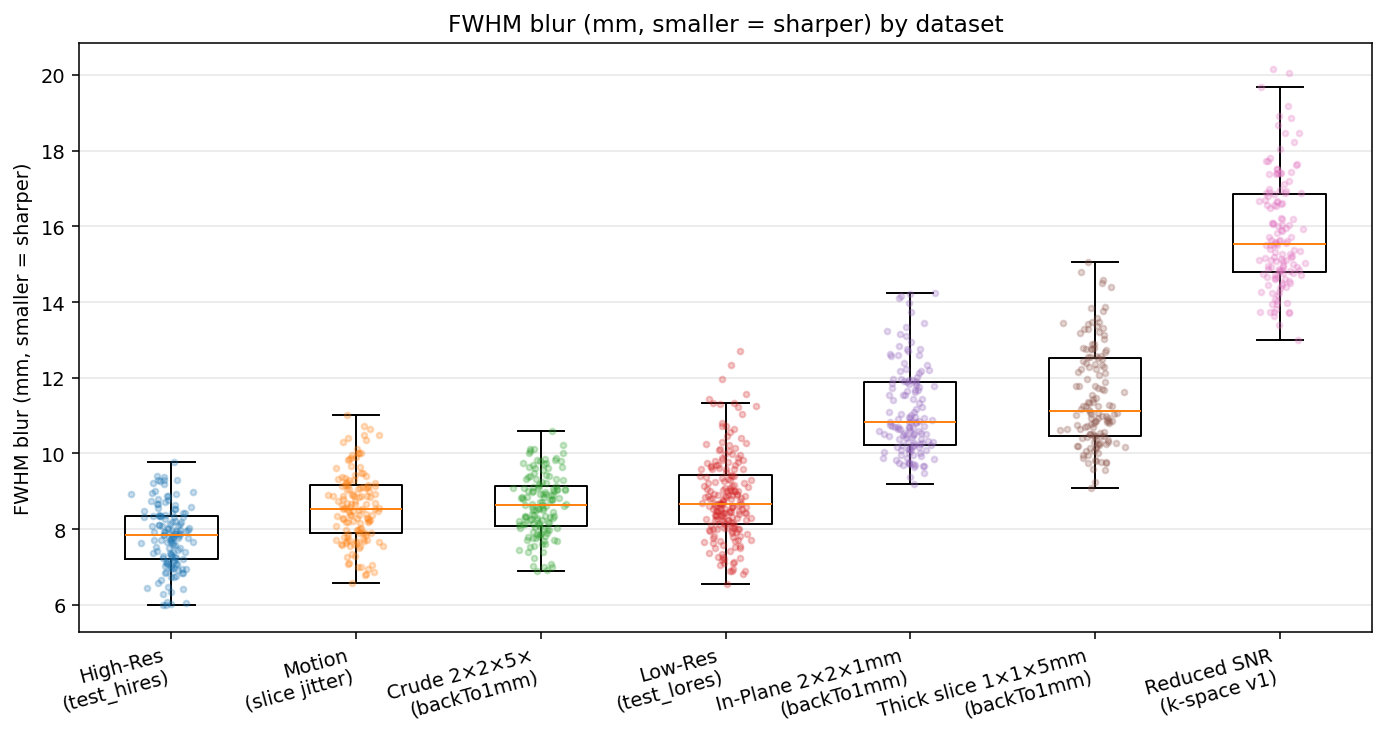

Saved _image_quality_eval_20251112_120355/box_fwhm.png


/tmp/ipykernel_2056658/4192611675.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[d.replace(" (","\n(") for d in order], showfliers=False)


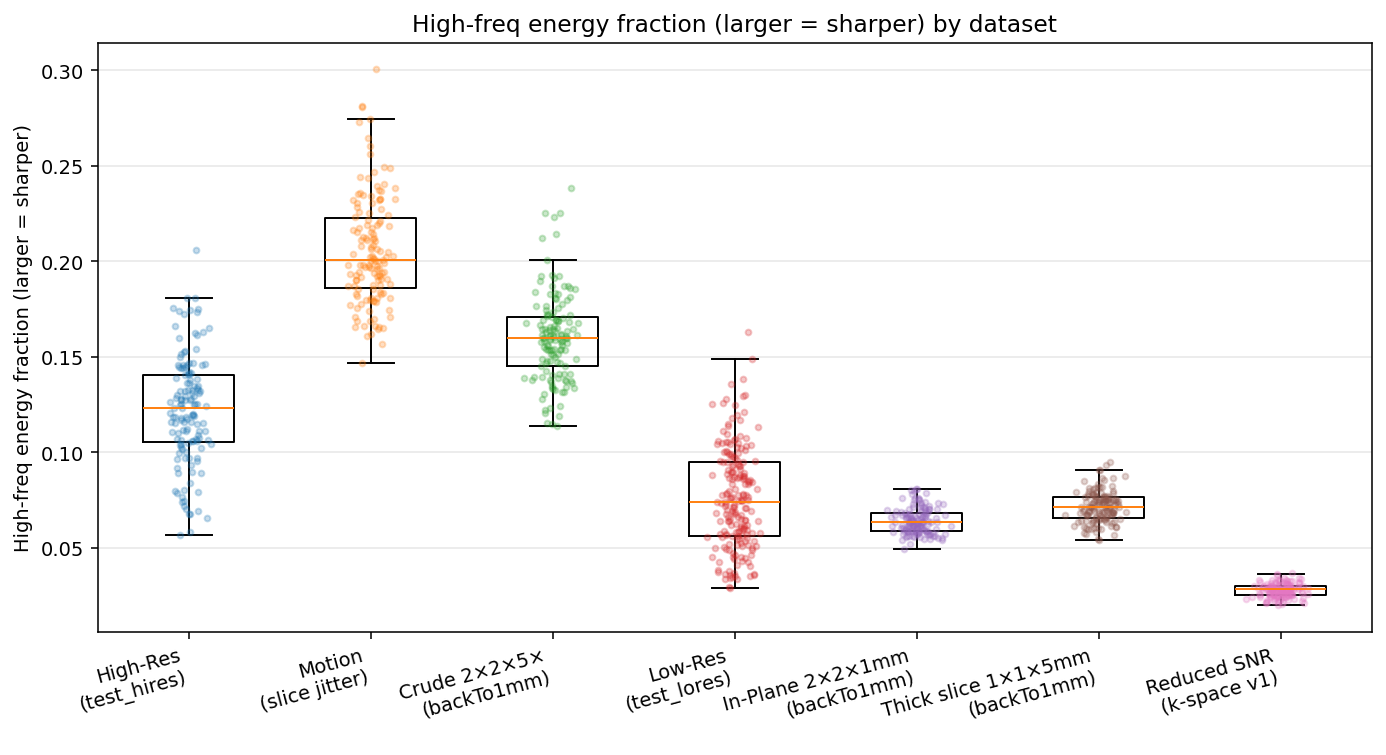

Saved _image_quality_eval_20251112_120355/box_hfe.png


/tmp/ipykernel_2056658/4192611675.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[d.replace(" (","\n(") for d in order], showfliers=False)


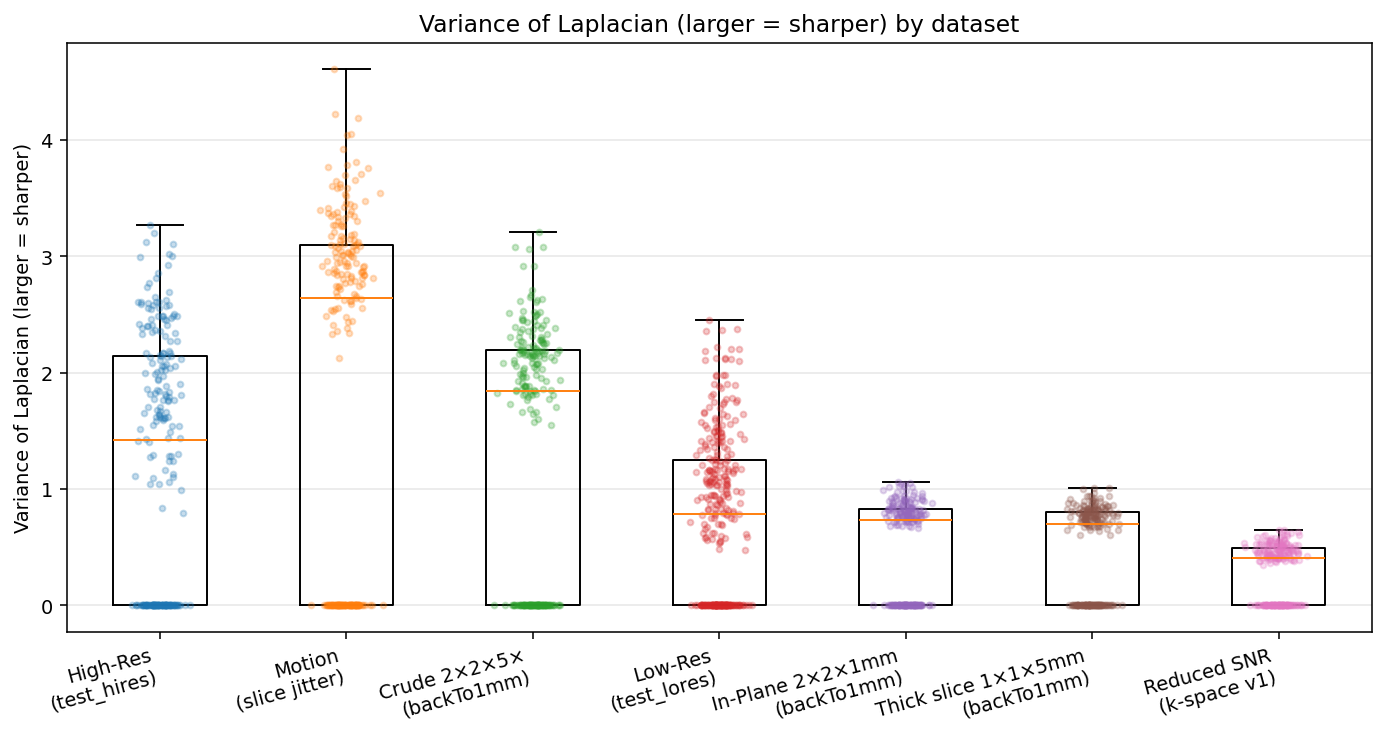

Saved _image_quality_eval_20251112_120355/box_lapvar.png


In [10]:
# consistent order: sort datasets by mean FWHM ascending (sharper first)
order = (df.groupby("dataset")["fwhm_mm"]
           .mean().sort_values(ascending=True).index.tolist())

def box_jitter(df, metric, ylabel, fname):
    fig = plt.figure(figsize=(10,5.5), dpi=140)
    ax = fig.add_subplot(111)
    data = [df[df["dataset"]==d][metric].dropna().values for d in order]
    ax.boxplot(data, labels=[d.replace(" (","\n(") for d in order], showfliers=False)
    # jitter
    for i, d in enumerate(order, start=1):
        v = df[df["dataset"]==d][metric].dropna().values
        if v.size==0: continue
        x = np.random.normal(i, 0.06, size=v.size)
        ax.plot(x, v, "o", alpha=0.25, markersize=3)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} by dataset")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    p = OUT_ROOT/f"box_{fname}.png"
    plt.savefig(p, dpi=200); plt.show()
    print("Saved", p)

box_jitter(df, "fwhm_mm", "FWHM blur (mm, smaller = sharper)", "fwhm")
box_jitter(df, "hi_freq_energy", "High-freq energy fraction (larger = sharper)", "hfe")
box_jitter(df, "lap_var", "Variance of Laplacian (larger = sharper)", "lapvar")


In [14]:
# ==== Display names, order, and colors ====
label_map = {
    "High-Res (test_hires)"              : "Higher Resolution",
    "Low-Res (test_lores)"               : "Lower Resolution",
    "Crude 2×2×5× (backTo1mm)"           : "Crude Downsample",
    "Thick slice 1×1×5mm (backTo1mm)"    : "Thick Slices",
    "In-Plane 2×2×1mm (backTo1mm)"       : "In-plane Coarsening",
    "Reduced SNR (k-space v1)"           : "Reduced SNR",
    "Motion (slice jitter)"              : "Rigid Jitter",
}

order_display = [
    "Higher Resolution",
    "Lower Resolution",
    "Crude Downsample",
    "Thick Slices",
    "In-plane Coarsening",
    "Reduced SNR",
    "Rigid Jitter",
]

# named colors (matplotlib) — using clear picks
color_map = {
    "Higher Resolution"   : "blue",
    "Lower Resolution"    : "red",
    "Crude Downsample"    : "green",
    "Thick Slices"        : "orange",
    "In-plane Coarsening" : "lightblue",  # you asked "light blue"
    "Reduced SNR"         : "purple",
    "Rigid Jitter"        : "pink",
}

# Make a display-labelled copy of df
df_disp = df.copy()
df_disp["display"] = df_disp["dataset"].map(label_map)
# keep only rows that mapped (the seven groups)
df_disp = df_disp[ df_disp["display"].isin(order_display) ].copy()

# If some groups are missing in the current df, keep order but drop missing
order_present = [d for d in order_display if d in df_disp["display"].unique()]


/tmp/ipykernel_2056658/3790147103.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


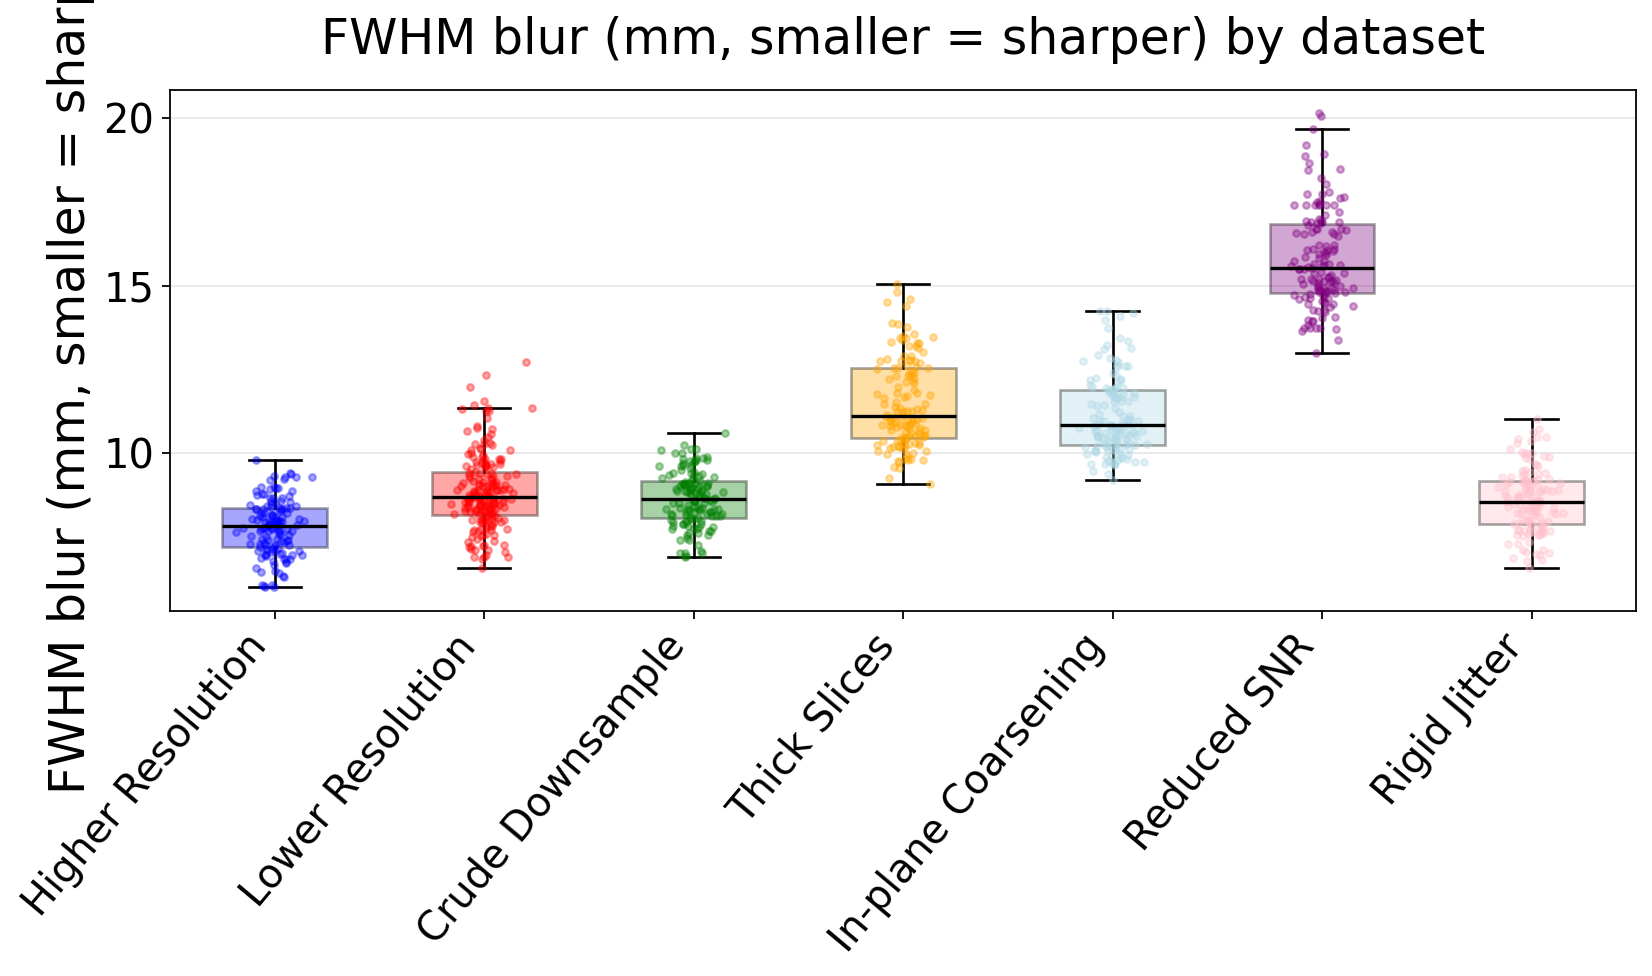

Saved _image_quality_eval_20251112_120355/box_fwhm_styled.png


/tmp/ipykernel_2056658/3790147103.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


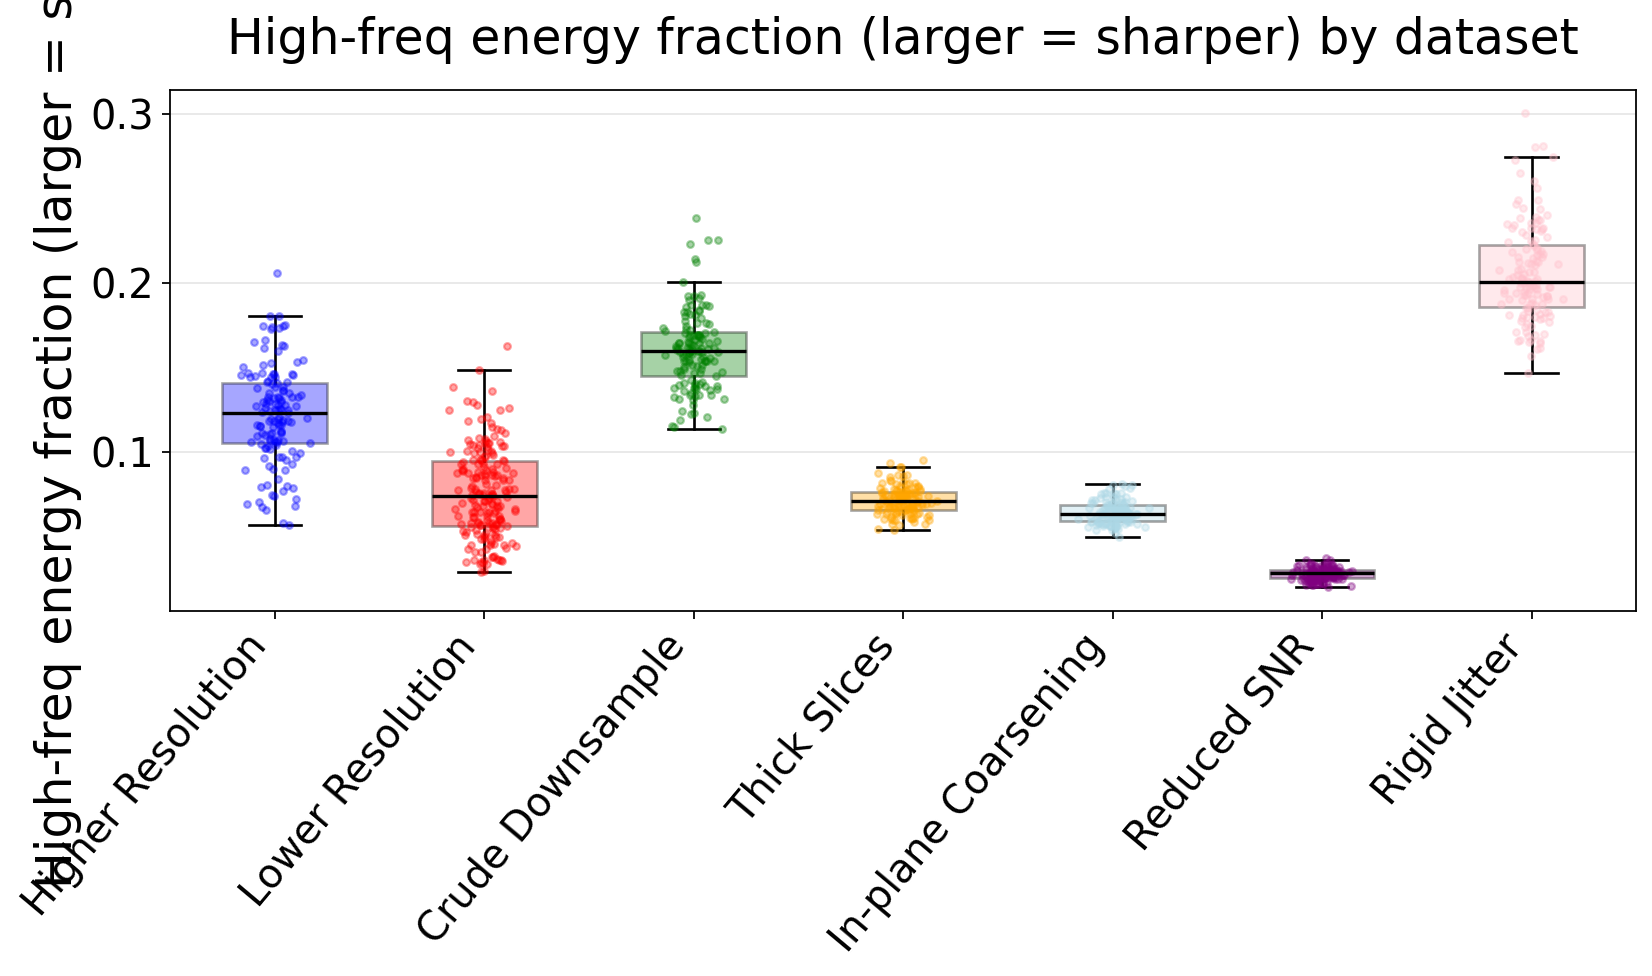

Saved _image_quality_eval_20251112_120355/box_hfe_styled.png


/tmp/ipykernel_2056658/3790147103.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


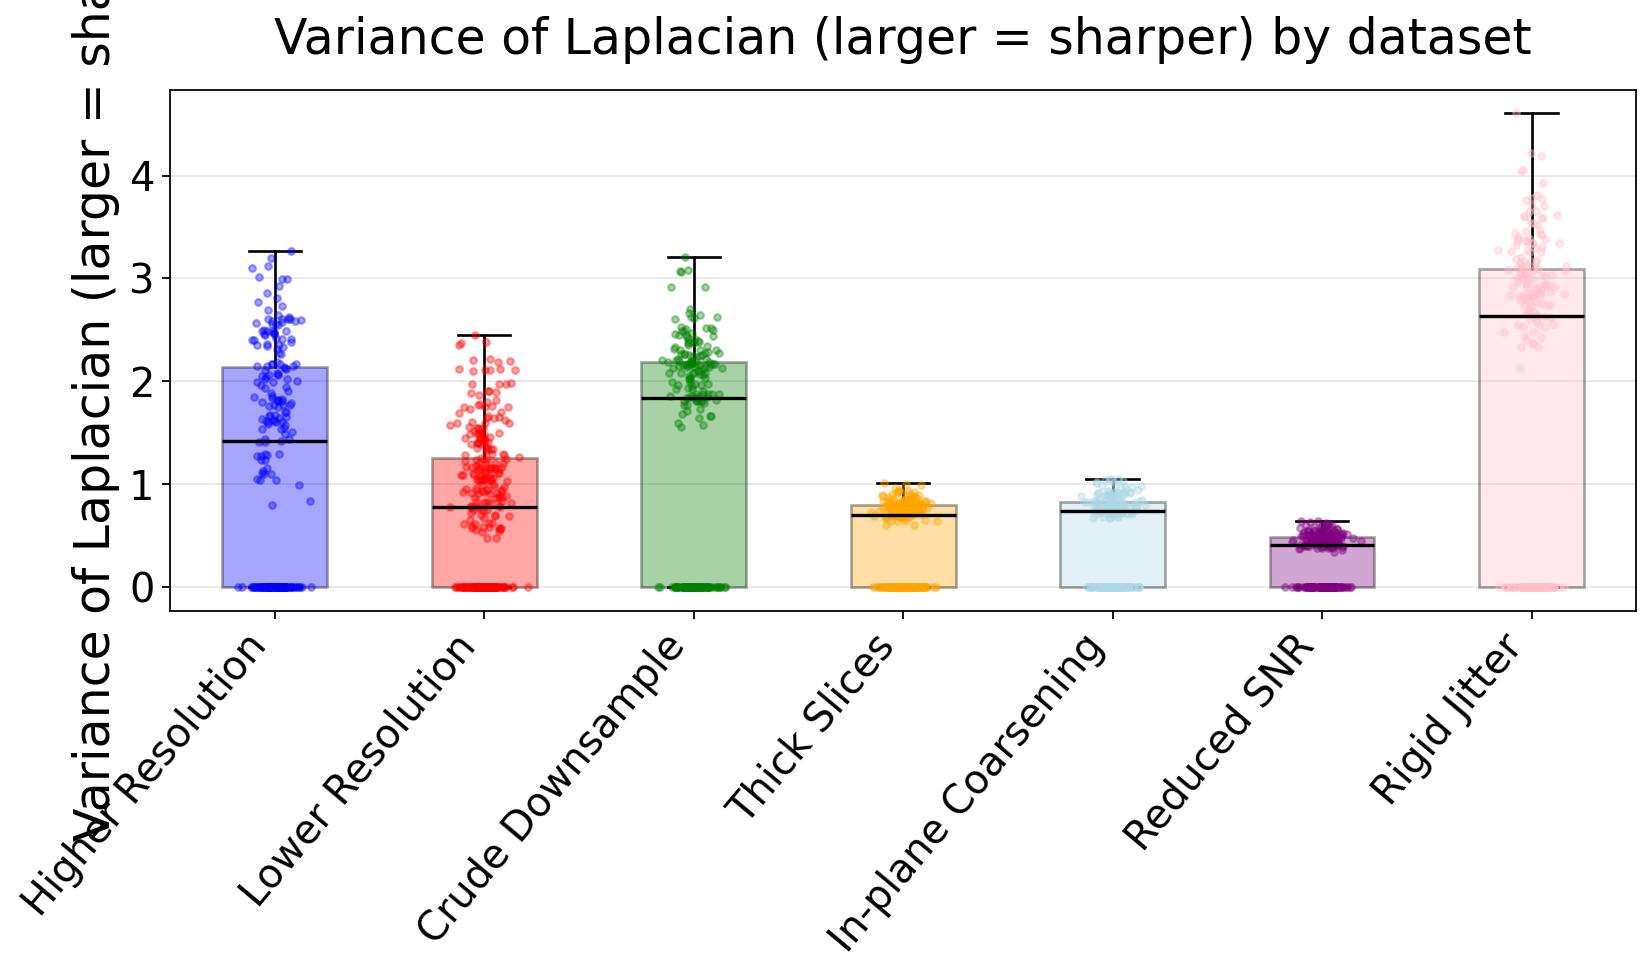

Saved _image_quality_eval_20251112_120355/box_lapvar_styled.png


In [18]:
import matplotlib.pyplot as plt
import numpy as np

def box_jitter_styled(df_use, metric, ylabel, fname):
    data = [df_use.loc[df_use["display"]==d, metric].dropna().values for d in order_present]

    fig = plt.figure(figsize=(10.5, 6.2), dpi=160)
    ax = fig.add_subplot(111)

    # colored boxes
    bp = ax.boxplot(
        data,
        labels=order_present,
        showfliers=False,
        patch_artist=True,  # <-- allows per-box facecolor
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        boxprops=dict(linewidth=1.2),
    )

    # set per-box face colors
    for patch, name in zip(bp['boxes'], order_present):
        patch.set_facecolor(color_map[name])
        patch.set_alpha(0.35)  # soft fill so medians stand out

    # jitter points, color-matched
    for i, name in enumerate(order_present, start=1):
        v = df_use.loc[df_use["display"]==name, metric].dropna().values
        if v.size == 0: 
            continue
        x = np.random.normal(i, 0.06, size=v.size)
        ax.plot(x, v, "o", markersize=3, alpha=0.35, color=color_map[name])

    ax.set_ylabel(ylabel, fontsize=22)
    ax.set_title(f"{ylabel} by dataset", fontsize=22, pad=16)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="both", labelsize=18)
    plt.xticks(rotation=50, ha="right")
    plt.tight_layout()
    p = OUT_ROOT/f"box_{fname}_styled.png"
    plt.savefig(p, dpi=220); plt.show()
    print("Saved", p)

# call for each metric
box_jitter_styled(df_disp, "fwhm_mm",       "FWHM blur (mm, smaller = sharper)", "fwhm")
box_jitter_styled(df_disp, "hi_freq_energy","High-freq energy fraction (larger = sharper)", "hfe")
box_jitter_styled(df_disp, "lap_var",       "Variance of Laplacian (larger = sharper)", "lapvar")


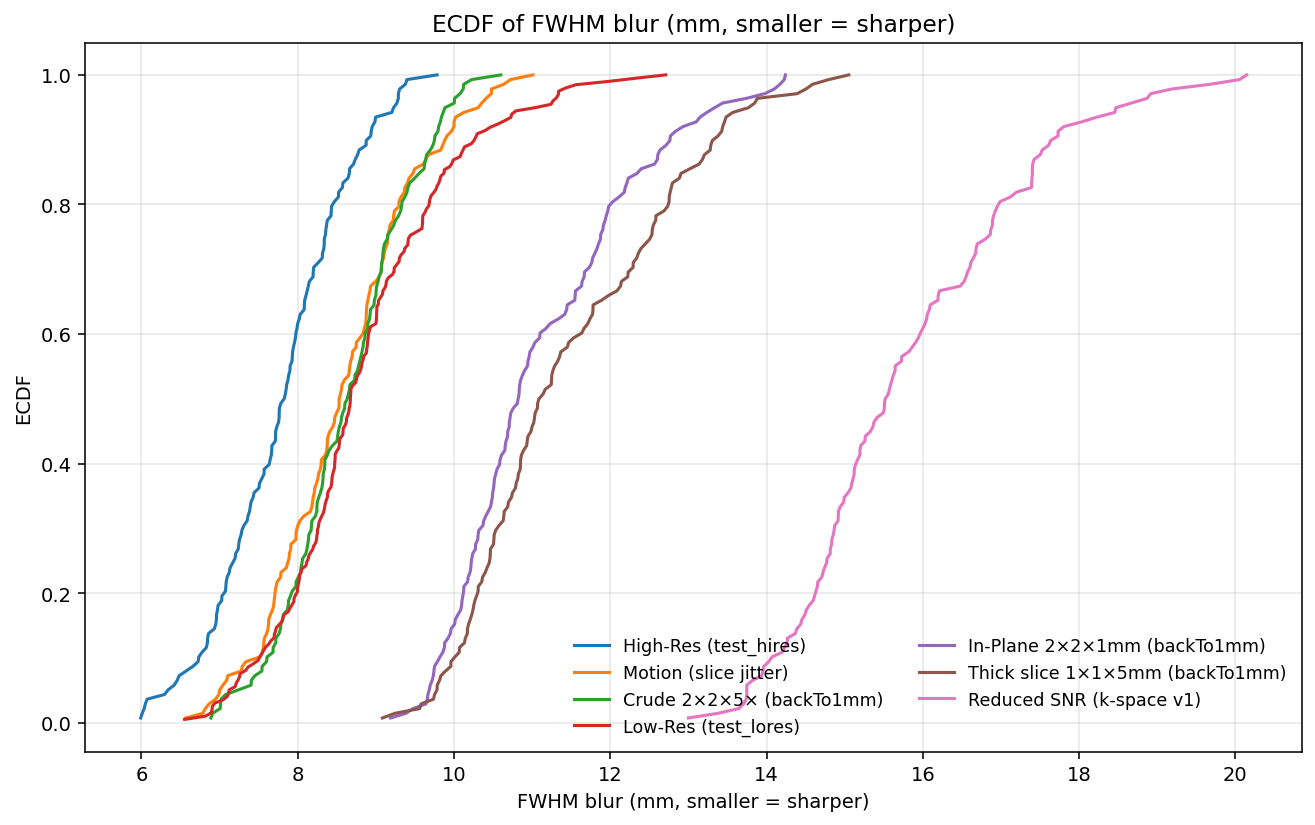

Saved _image_quality_eval_20251112_120355/ecdf_fwhm.png


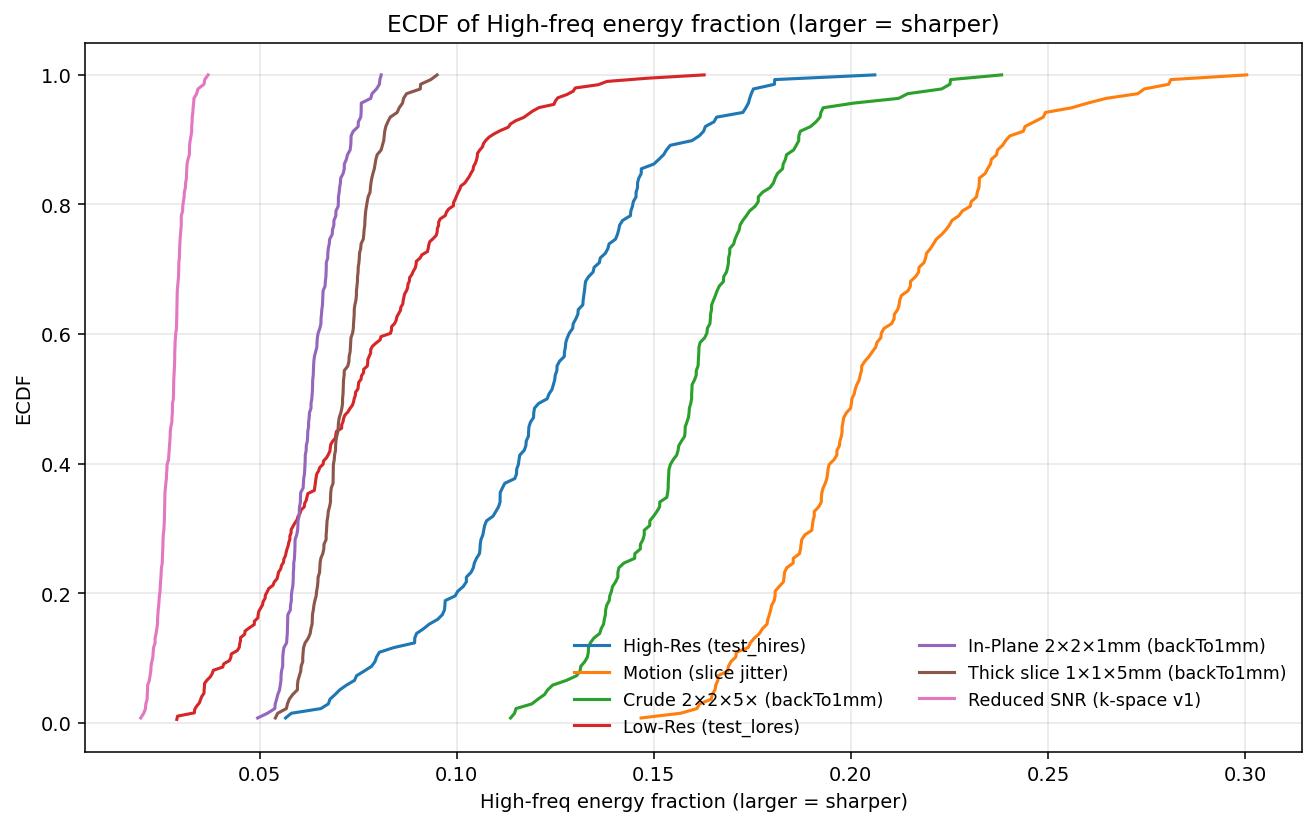

Saved _image_quality_eval_20251112_120355/ecdf_hfe.png


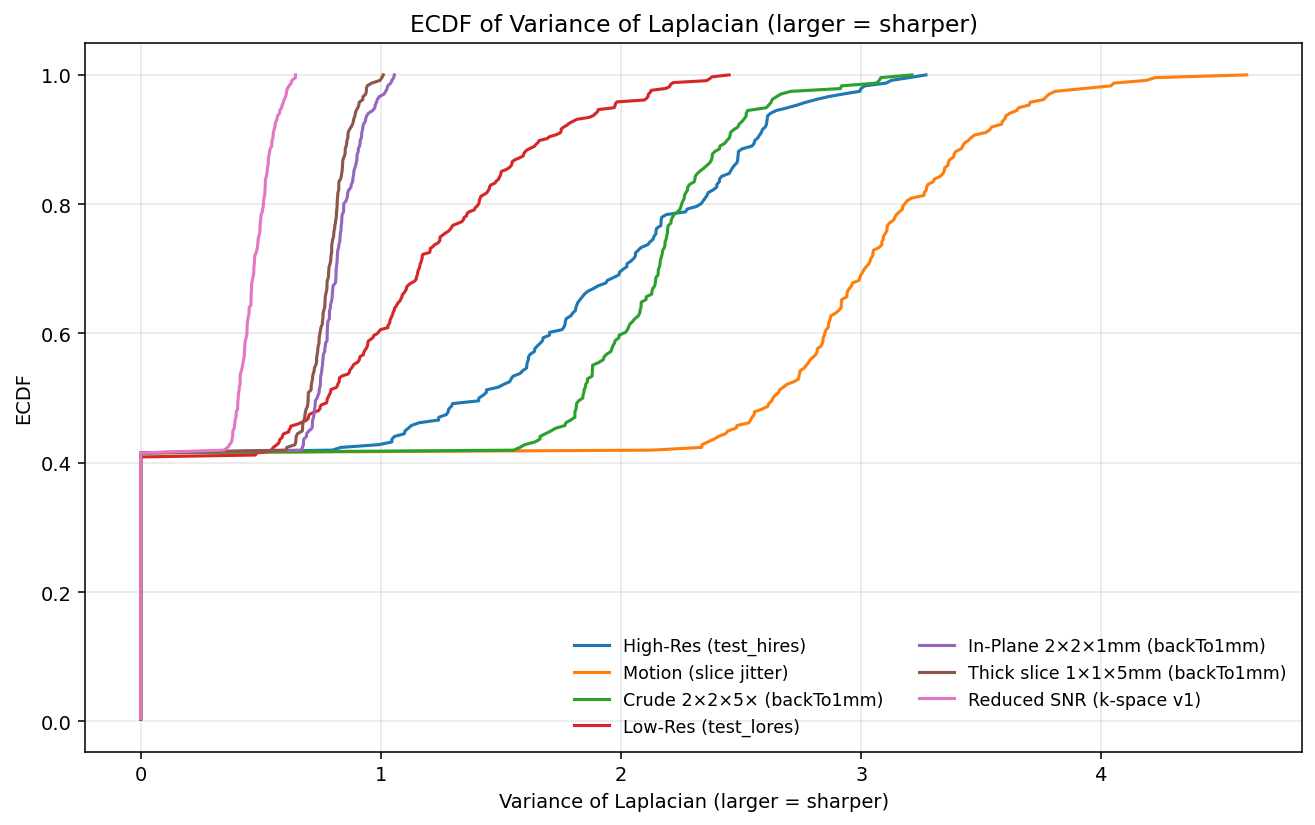

Saved _image_quality_eval_20251112_120355/ecdf_lapvar.png


In [11]:
def ecdf(a):
    a = np.asarray(a); a = a[~np.isnan(a)]
    if a.size==0: return np.array([]), np.array([])
    a = np.sort(a)
    y = np.arange(1, a.size+1)/a.size
    return a, y

def ecdf_plot(metric, xlabel, fname):
    fig = plt.figure(figsize=(9.5,6), dpi=140); ax = fig.add_subplot(111)
    for d in order:
        v = df[df["dataset"]==d][metric].values
        x, y = ecdf(v)
        if x.size==0: continue
        ax.plot(x, y, lw=1.6, label=d)
    ax.set_xlabel(xlabel); ax.set_ylabel("ECDF")
    ax.set_title(f"ECDF of {xlabel}")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False, fontsize=9, ncol=2)
    plt.tight_layout()
    p = OUT_ROOT/f"ecdf_{fname}.png"
    plt.savefig(p, dpi=200); plt.show()
    print("Saved", p)

ecdf_plot("fwhm_mm", "FWHM blur (mm, smaller = sharper)", "fwhm")
ecdf_plot("hi_freq_energy", "High-freq energy fraction (larger = sharper)", "hfe")
ecdf_plot("lap_var", "Variance of Laplacian (larger = sharper)", "lapvar")


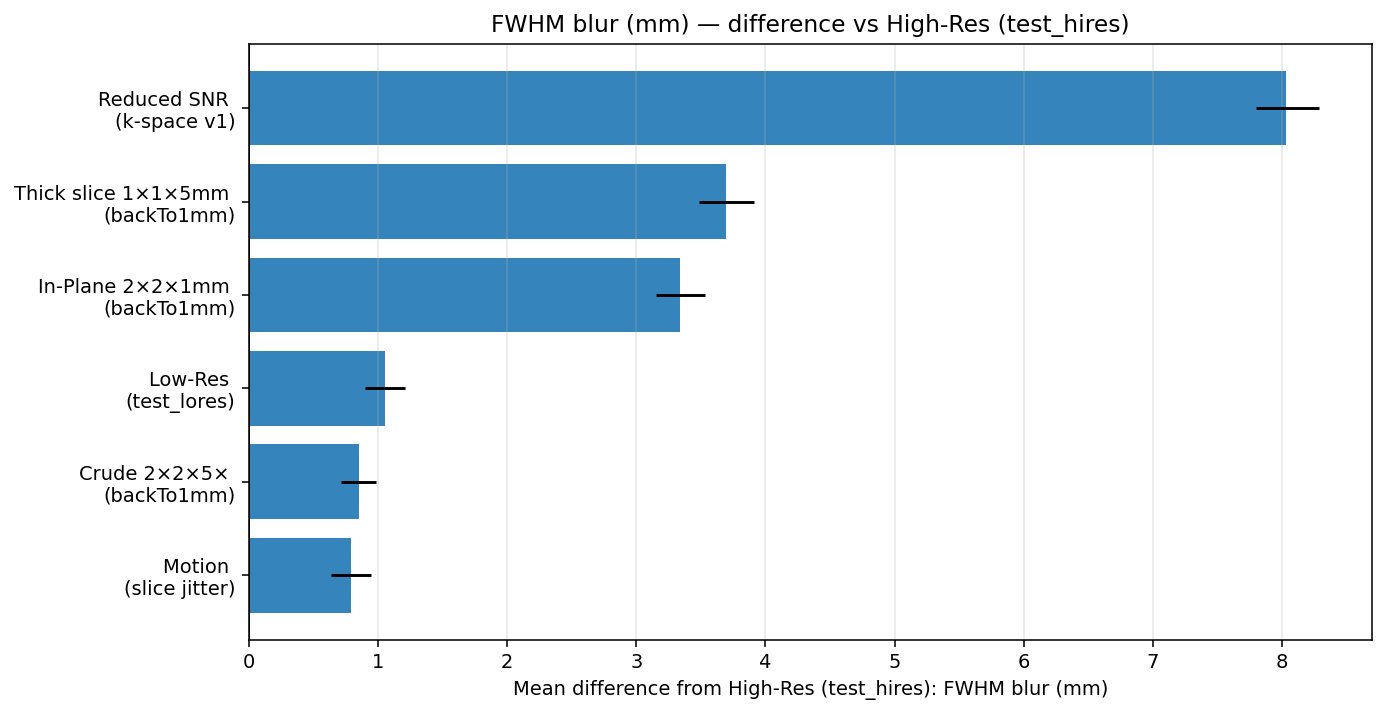

Saved _image_quality_eval_20251112_120355/diff_from_highres_fwhm.png


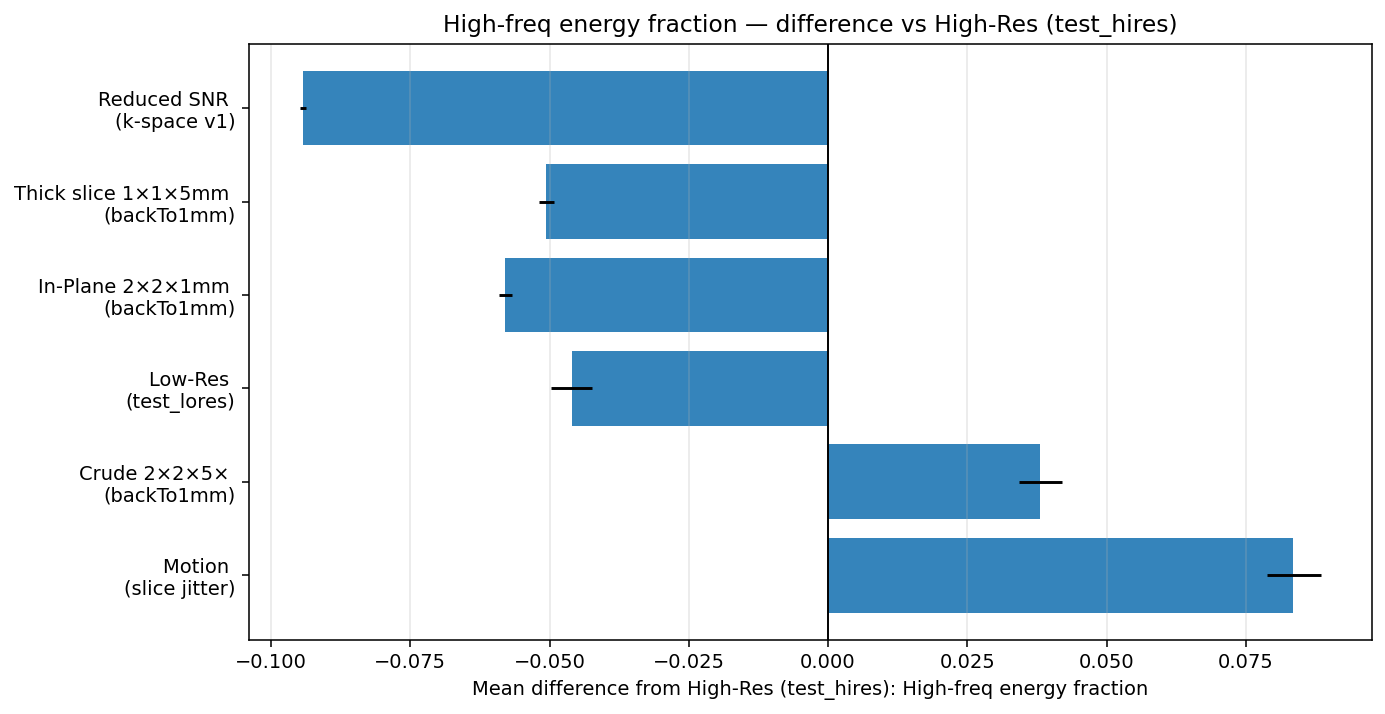

Saved _image_quality_eval_20251112_120355/diff_from_highres_hfe.png


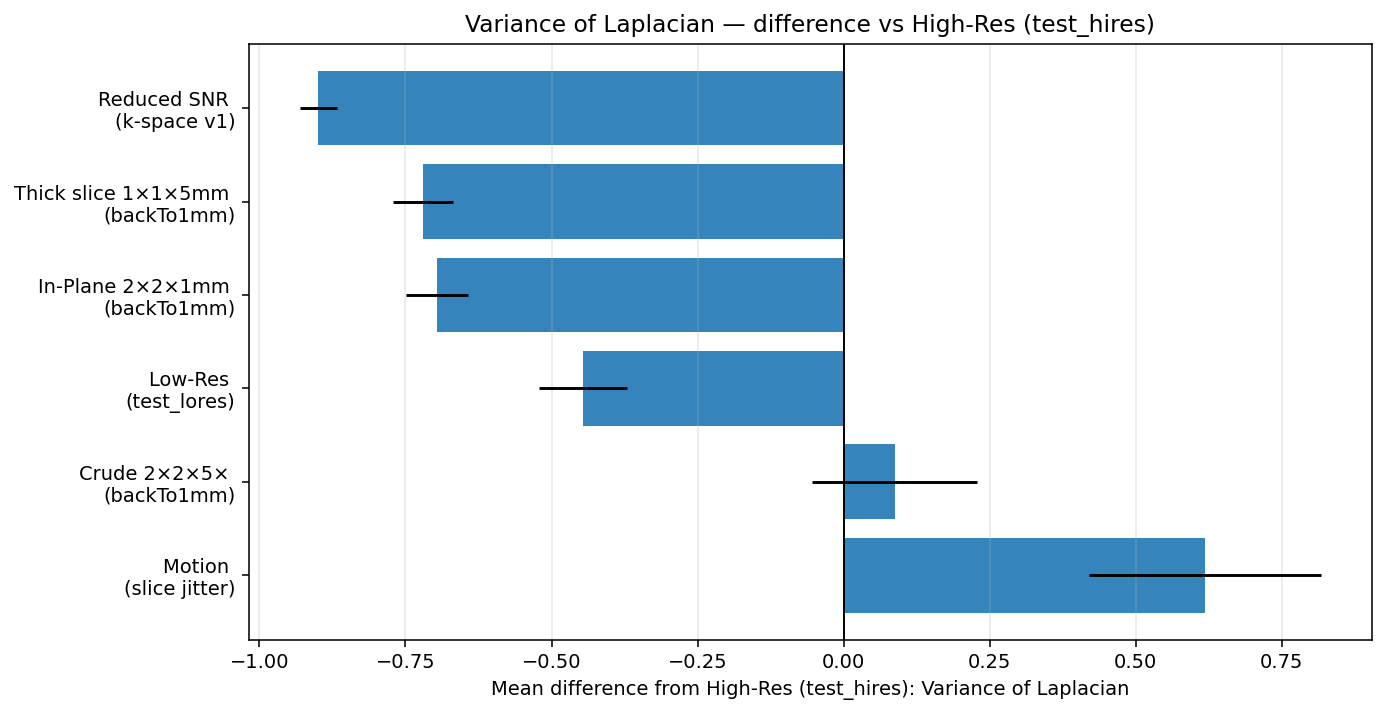

Saved _image_quality_eval_20251112_120355/diff_from_highres_lapvar.png


In [12]:
BASE = BASE_HI

def diff_from_base_plot(metric, ylabel, fname):
    base_vals = df[df["dataset"]==BASE][metric].values
    mu_base, _ = bootstrap_mean_ci(base_vals, nboot=4000, random_state=1)

    names, diffs, lo_ci, hi_ci = [], [], [], []
    for d in order:
        if d == BASE: continue
        v = df[df["dataset"]==d][metric].values
        mu, (lo, hi) = bootstrap_mean_ci(v, nboot=4000, random_state=2)
        names.append(d)
        diffs.append(mu - mu_base)
        lo_ci.append(lo - mu_base)
        hi_ci.append(hi - mu_base)

    fig = plt.figure(figsize=(10,5.2), dpi=140); ax = fig.add_subplot(111)
    y = np.arange(len(names))
    ax.barh(y, diffs, xerr=[np.array(diffs)-np.array(lo_ci), np.array(hi_ci)-np.array(diffs)], alpha=0.9)
    ax.set_yticks(y)
    ax.set_yticklabels([n.replace(" ("," \n(") for n in names])
    ax.axvline(0, color="k", lw=1)
    ax.set_xlabel(f"Mean difference from {BASE}: {ylabel}")
    ax.set_title(f"{ylabel} — difference vs {BASE}")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    p = OUT_ROOT/f"diff_from_highres_{fname}.png"
    plt.savefig(p, dpi=200); plt.show()
    print("Saved", p)

diff_from_base_plot("fwhm_mm", "FWHM blur (mm)", "fwhm")
diff_from_base_plot("hi_freq_energy", "High-freq energy fraction", "hfe")
diff_from_base_plot("lap_var", "Variance of Laplacian", "lapvar")


In [ ]:
def nice_pct(x):
    return "NA" if not np.isfinite(x) else f"{x:+.1f}%"

def assemble_report(df, stats_hi, stats_lo):
    lines = []
    lines.append("# Image Quality Metrics Report\n")
    lines.append(f"_Run: {RUN_TAG}_\n")
    lines.append("## Datasets\n")
    for k,v in DATASETS.items():
        lines.append(f"- **{k}**  \n  Path: `{v}`")
    lines.append("\n---\n")
    lines.append("## Percentile Summaries")
    lines.append("```\n" + summarize_df(df) + "\n```")

    def block(title, stats_df, base):
        lines.append(f"\n## Comparisons vs {base}\n")
        for metric, label in [("fwhm_mm","FWHM blur (mm, smaller=sharper)"),
                              ("hi_freq_energy","High-freq energy fraction (larger=sharper)"),
                              ("lap_var","Variance of Laplacian (larger=sharper)")]:
            lines.append(f"### {label}")
            sub = stats_df[stats_df["metric"]==metric].copy()
            if sub.empty:
                lines.append("_No data_\n"); continue
            # Order by percent change magnitude
            sub = sub.sort_values("pct_vs_base", ascending=False)
            for _, r in sub.iterrows():
                lines.append(
                    f"- **{r['dataset']}**: mean={r['mean_group']:.4f} "
                    f"(CI {r['ci_lo']:.4f}..{r['ci_hi']:.4f}) vs base {r['mean_base']:.4f}; "
                    f"Δ%={nice_pct(r['pct_vs_base'])}; "
                    f"Mann–Whitney U p={r['p']:.3g}; Cliff’s δ={r['cliffs_delta']:.3f}"
                )
            lines.append("")
    block("vs High-Res", stats_hi, "High-Res")
    block("vs Low-Res",  stats_lo, "Low-Res")

    return "\n".join(lines)

report_md = assemble_report(df, stats_vs_hi, stats_vs_lo)
(OUT_ROOT/"report.md").write_text(report_md)
print((OUT_ROOT/"report.md").resolve())

/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/_image_quality_eval_20251112_120355/report.md
